In [ ]:
from google.colab import files
files.upload()

Saving archive (5).zip to archive (5).zip


In [ ]:
!unzip "archive (5).zip"

Archive:  archive (5).zip
  inflating: Data/test/adenocarcinoma/000108 (3).png  
  inflating: Data/test/adenocarcinoma/000109 (2).png  
  inflating: Data/test/adenocarcinoma/000109 (4).png  
  inflating: Data/test/adenocarcinoma/000109 (5).png  
  inflating: Data/test/adenocarcinoma/000112 (2).png  
  inflating: Data/test/adenocarcinoma/000113 (7).png  
  inflating: Data/test/adenocarcinoma/000114 (5).png  
  inflating: Data/test/adenocarcinoma/000114.png  
  inflating: Data/test/adenocarcinoma/000115 (4).png  
  inflating: Data/test/adenocarcinoma/000115 (8).png  
  inflating: Data/test/adenocarcinoma/000115.png  
  inflating: Data/test/adenocarcinoma/000116 (5).png  
  inflating: Data/test/adenocarcinoma/000116 (7).png  
  inflating: Data/test/adenocarcinoma/000116 (9).png  
  inflating: Data/test/adenocarcinoma/000117 (4).png  
  inflating: Data/test/adenocarcinoma/000117 (8).png  
  inflating: Data/test/adenocarcinoma/000117.png  
  inflating: Data/test/adenocarcinoma/000118 (5).pn

In [ ]:
import os

train_dir = "/content/Data/train"

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        print(cls, "->", len(os.listdir(cls_path)))

cancer -> 0
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa -> 155
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa -> 115
normal -> 148
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib -> 195


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


# PATH (COLAB)
train_dir = "/content/Data/train"

In [ ]:
# PARAMETERS

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10

In [ ]:
# DATA GENERATOR

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    directory=train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    directory=train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)
print("Classes:", train_data.class_indices)
print("Training samples:", train_data.samples)
print("Validation samples:", val_data.samples)

Found 491 images belonging to 5 classes.
Found 122 images belonging to 5 classes.
Classes: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'cancer': 1, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 2, 'normal': 3, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 4}
Training samples: 491
Validation samples: 122


In [ ]:
# CNN MODEL

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])
model.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,957 (84.86 MB)

 Trainable params: 22,245,957 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# TRAIN

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.3045 - loss: 1.4662 - val_accuracy: 0.4836 - val_loss: 1.2113
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.4869 - loss: 1.1782 - val_accuracy: 0.6148 - val_loss: 0.9620
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.6323 - loss: 0.9261 - val_accuracy: 0.6639 - val_loss: 0.8107
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.7562 - loss: 0.6988 - val_accuracy: 0.7705 - val_loss: 0.5695
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.8173 - loss: 0.5057 - val_accuracy: 0.6721 - val_loss: 0.7443
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.7884 - loss: 0.5292 - val_accuracy: 0.8197 - val_loss: 0.4815
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.8730 - loss: 0.3470 - val_accuracy: 0.8525 - val_loss: 0.4186
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.9178 - loss: 0.2613 - val_accuracy: 0.8689 - val_loss:

In [ ]:
# SAVE MODEL

model.save("lung_cancer_ct_model.h5")
print(" Model saved")

 Model saved


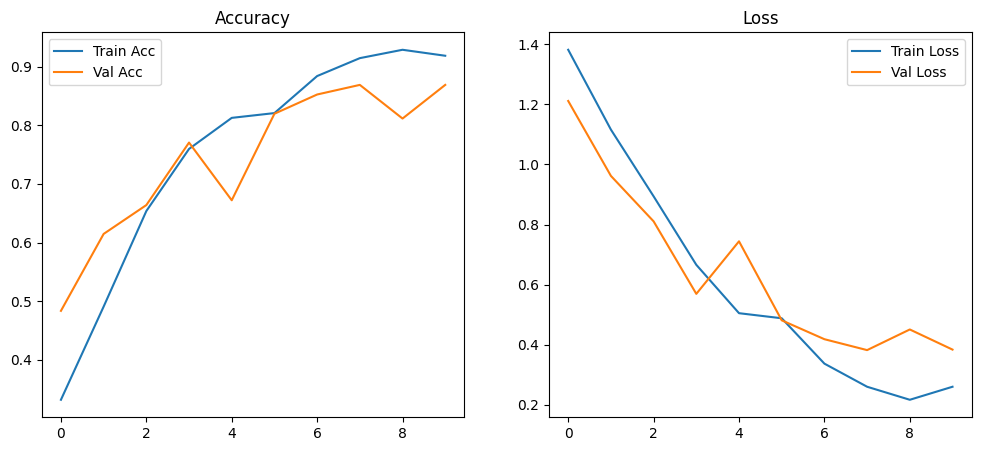

In [ ]:
# PLOT RESULTS

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    if "train" in dirs:
        print("FOUND TRAIN PATH ", os.path.join(root, "train"))

FOUND TRAIN PATH  /content/Data/train


In [ ]:
train_dir = "/content/Data/train"

In [ ]:
for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        print(cls, "->", len(os.listdir(cls_path)))

cancer -> 0
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa -> 155
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa -> 115
normal -> 148
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib -> 195


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


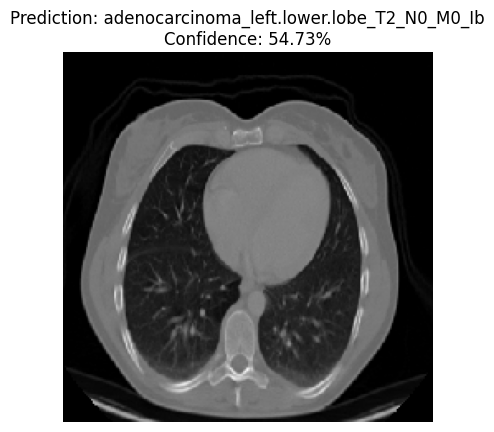

Predicted Class: adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
Confidence: 54.73%


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt


# LOAD TRAINED MODEL

model = tf.keras.models.load_model("lung_cancer_ct_model.h5")


# CLASS LABELS (AUTO FROM TRAINING)

# Use the actual class names from the training data
class_names = [
    'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
    'cancer',
    'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa',
    'normal',
    'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa'
]


# LOAD IMAGE

# Provide a direct path to one of the images from the unzipped dataset
img_path = '/content/Data/test/adenocarcinoma/000108 (3).png'

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)


# PREDICTION

predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions) * 100


# SHOW RESULT

plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

In [ ]:
# PREDICT

pred = model.predict(img_array)
predicted_index = np.argmax(pred)
predicted_label = class_names[predicted_index]
confidence = np.max(pred) * 100

# NORMAL vs CANCER LOGIC

if predicted_label == "normal":
    final_result = "NORMAL"
else:
    final_result = "CANCER"


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


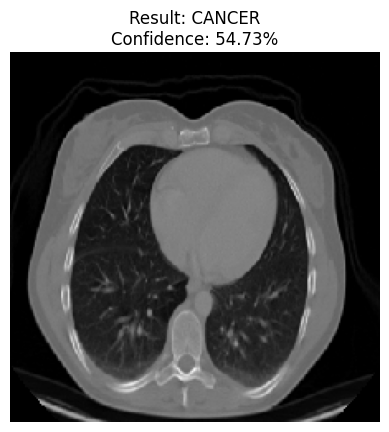

Detailed Class Prediction: adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
Final Output: CANCER
Confidence: 54.73%


In [ ]:
# DISPLAY RESULT

plt.imshow(img)
plt.axis("off")
plt.title(f"Result: {final_result}\nConfidence: {confidence:.2f}%")
plt.show()

print("Detailed Class Prediction:", predicted_label)
print("Final Output:", final_result)
print("Confidence:", f"{confidence:.2f}%")

In [ ]:
import random
import os
from os import listdir # Explicitly import listdir

# Assuming 'normal' is a class within train_dir
normal_dir = os.path.join(train_dir, 'normal')

# Filter out 'normal' and 'cancer' (if 'cancer' is an empty dir as observed before)
cancer_dirs = [cls for cls in listdir(train_dir) if os.path.isdir(os.path.join(train_dir, cls)) and cls not in ['normal', 'cancer']]

# Ensure these directories exist before trying to list them
if os.path.exists(normal_dir) and listdir(normal_dir):
    normal_img = random.choice(listdir(normal_dir))
else:
    normal_img = None # Handle case where normal_dir is empty or doesn't exist
    print("Warning: 'normal' directory is empty or does not exist.")

if cancer_dirs:
    cancer_class = random.choice(cancer_dirs)
    cancer_class_path = os.path.join(train_dir, cancer_class)
    if listdir(cancer_class_path):
        cancer_img = random.choice(listdir(cancer_class_path))
    else:
        cancer_img = None
        print(f"Warning: '{cancer_class}' directory is empty.")
else:
    cancer_class = None
    cancer_img = None
    print("Warning: No valid cancer classes found in train_dir.")


normal_path = os.path.join(normal_dir, normal_img) if normal_img else None
cancer_path = os.path.join(train_dir, cancer_class, cancer_img) if cancer_img else None

print("Normal image path:", normal_path)
print("Cancer image path:", cancer_path)

Normal image path: /content/Data/train/normal/8 - Copy.png
Cancer image path: /content/Data/train/large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa/000051.png


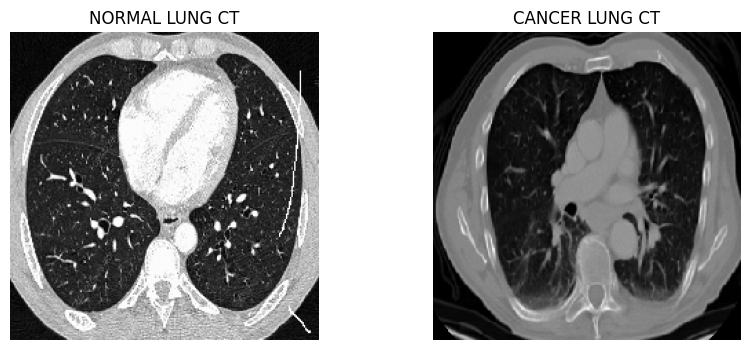

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image.load_img(normal_path, target_size=(224,224)))
plt.title("NORMAL LUNG CT")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(image.load_img(cancer_path, target_size=(224,224)))
plt.title("CANCER LUNG CT")
plt.axis("off")

plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 620ms/step


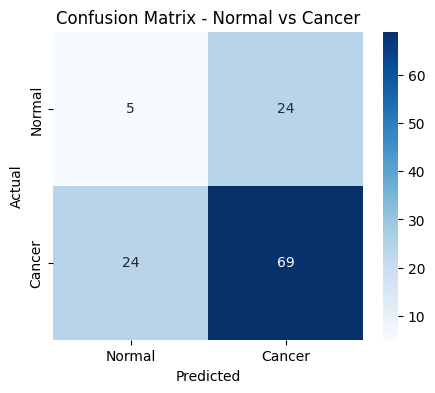

              precision    recall  f1-score   support

      Normal       0.17      0.17      0.17        29
      Cancer       0.74      0.74      0.74        93

    accuracy                           0.61       122
   macro avg       0.46      0.46      0.46       122
weighted avg       0.61      0.61      0.61       122



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict
val_data.reset()
y_true_multi_class = val_data.classes # Keep original multi-class labels
predictions = model.predict(val_data)
predicted_classes_multi_class = np.argmax(predictions, axis=1)

# Map multi-class labels to binary 'Normal' (0) or 'Cancer' (1)
# Assuming 'normal' class index is 3 based on previous output: Classes: {... 'normal': 3 ...}
normal_class_index = 3

y_true = np.where(y_true_multi_class == normal_class_index, 0, 1) # 0 for Normal, 1 for Cancer
y_pred = np.where(predicted_classes_multi_class == normal_class_index, 0, 1) # 0 for Normal, 1 for Cancer

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Cancer"],
            yticklabels=["Normal", "Cancer"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Normal vs Cancer")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=["Normal", "Cancer"]))